# Exercise 6: Reserves

**Presenter** <br>
Priyesh Gosai <br>
Energy Systems Modeller <br>
priyesh@innovateimpact.com <br>

**Course Details**<br>
Modelling Integrated Power Markets <br>
Johannesburg, South Africa <br>
20-24 April 2026 <br>


In [1]:
lesson_number = 6
print(f'lesson{lesson_number}')

lesson6


## Prepare Google Colab Environment

In [2]:
#@title Connect to Google Drive {display-mode:"form"}
CONNECT_TO_DRIVE = False #@param {type:"boolean"}

import os
if 'lesson_number' not in locals(): lesson_number = 6

if CONNECT_TO_DRIVE:
    from google.colab import drive
    # Mount Google Drive
    drive.mount('/content/drive')

    # Define the desired working directory path
    working_dir = f'/content/drive/MyDrive/ich-modelling-2026'
    lesson_folder = f'lesson-{lesson_number}'
    lesson_dir = os.path.join(working_dir, lesson_folder)

    # Create the working directory if it doesn't exist
    if not os.path.exists(working_dir):
        os.makedirs(working_dir)
        print(f"Directory '{working_dir}' created.")
    else:
        print(f"Directory '{working_dir}' already exists.")

    # Create the lesson directory if it doesn't exist
    if not os.path.exists(lesson_dir):
        os.makedirs(lesson_dir)
        print(f"Directory '{lesson_dir}' created.")
    else:
        print(f"Directory '{lesson_dir}' already exists.")

    # Change the current working directory to the lesson directory
    os.chdir(lesson_dir)

    print(f"Current working directory: {os.getcwd()}")
else:
    print("Not connecting to Google Drive.")

Not connecting to Google Drive.


In [3]:
#@title Install Packages {display-mode:"form"}
INSTALL_PACKAGES = False #@param {type:"boolean"}

import os

# Check if packages have already been installed in this session to prevent re-installation
if INSTALL_PACKAGES and not os.environ.get('PYPSA_PACKAGES_INSTALLED'):
  !pip install pypsa
  !pip install pypsa[excel] 
  !pip install folium mapclassify cartopy gurobipy
  os.environ['PYPSA_PACKAGES_INSTALLED'] = 'true'
elif not INSTALL_PACKAGES:
  print("Skipping package installation.")
else:
  print("PyPSA packages are already installed for this session.")

Skipping package installation.


In [4]:
#@title Download the file for this notebook {display-mode:"form"}
DOWNLOAD_FILE = False #@param {type:"boolean"}

import urllib.request
import os

if DOWNLOAD_FILE:
    url = "https://raw.githubusercontent.com/PriyeshGosai/ich_course_2026/46e109dd68c635d83046eec03d2d2a4afc669366/n-01-single-node-v2.xlsx"
    file_name = url.split('/')[-1]  # Extract filename from URL
    filename = file_name
    urllib.request.urlretrieve(url, filename)
    print(f"File downloaded successfully: {os.path.abspath(filename)}")

else:
    print("Skipping file download.")

Skipping file download.


#### Case Description

This case demonstrates a method for co-optimising reserves using custom constraints. 

##### PyPSA Features Used

| Feature | Method |
|---------|--------|
|Custom constraints | Programmatically |


##### Non-Standard PyPSA Features

These features are not standard in PyPSA but can be implemented through component manipulation:

| Feature | Method |
|---------|--------|
| Reserve calculation | programatically |

#### Lesson Tasks

1. Review the approach used for modelling reserves. 
2. Run scenarios where you consider different amounts of reserve [100, 200, 400].  

## Model

In [5]:
file_name = 'n_02_single_node_v2.xlsx'

week = 10 # False : Insert week number (1-52) or False for full year simulation

In [6]:
# Import packages
import pypsa
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import xarray as xr

pd.set_option('future.no_silent_downcasting', True)
pd.set_option('plotting.backend', 'plotly')
pypsa.options.api.new_components_api = True

n = pypsa.Network(file_name)   

if week is not False: n.set_snapshots(n.snapshots[n.snapshots.isocalendar().week == week])

selected_generators = ['Athlone Coal 1',
                        'Ankerlig Gas',
                        'Salt River Coal 1',
                        'Salt River Coal 2',
                        'Future OCGT']


total_reserves = 400

INFO:pypsa.network.io:Imported network 'ich-single-node-model' has buses, carriers, generators, global_constraints, lines, line_types, links, loads, processes, shapes, shunt_impedances, storage_units, stores, sub_networks, transformers, transformer_types


In [7]:
# Create model
n.optimize.create_model()

# Add reserve variable
v_rp = n.model.add_variables(
    lower=0,
    coords={"snapshot": list(n.snapshots), "name": selected_generators},
    dims=["snapshot", "name"],
    name="Generator-p_reserve",
)

# Get references
p_selected = n.model.variables["Generator-p"].sel(name=selected_generators)
p_nom_array = xr.DataArray(
    n.generators.static.loc[selected_generators, "p_nom"].values,
    coords={"name": selected_generators},
    dims=["name"],
)

# Add constraints
n.model.add_constraints(
    v_rp + p_selected <= p_nom_array,
    name="Generator-reserve_headroom",
)

n.model.add_constraints(
    v_rp <= 0.7 * p_selected,
    name="Generator-reserve_downward_limit",
)

n.model.add_constraints(
    v_rp.sum("name") >= total_reserves,
    name="GlobalConstraint-reserve_requirement",
)

# Solve
n.optimize.solve_model()

C:\Users\PriyeshGosai\AppData\Local\Temp\ipykernel_46212\3936622126.py:2: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize.create_model()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.12s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 5040 primals, 11754 duals
Objective: 9.26e+07
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-p-ramp_limit_up, Generator-p-ramp_limit_down, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_cha

('ok', 'optimal')

## Post-process

In [8]:


print("\n" + "="*80)
print("EXTRACTING RESULTS")
print("="*80)

# CORRECT: Get the reserve variable using .solution
reserves = n.model.variables["Generator-p_reserve"].solution.to_pandas()
print(f"\nReserves shape: {reserves.shape}")
print(f"Reserves columns (generators): {reserves.columns.tolist()}")
print("\nReserves (first 10 snapshots):")
print(reserves.head(10))

# CORRECT: Get power generation using .solution
power = n.model.variables["Generator-p"].solution.to_pandas()
print(f"\nPower shape: {power.shape}")
print(f"Power columns (generators): {power.columns.tolist()}")
print("\nPower (first 10 snapshots):")
print(power.head(10))

# Get load
load = n.loads.dynamic.p_set
print(f"\nLoad shape: {load.shape}")
print(f"Load columns: {load.columns.tolist()}")
print("\nLoad (first 10 snapshots):")
print(load.head(10))

# ============================================================================
# BASIC CHECKS
# ============================================================================

print("\n" + "="*80)
print("BASIC CHECKS")
print("="*80)

# Total load (sum across all load points)
total_load = load.sum(axis=1)
print(f"\nTotal load per snapshot:")
print(f"  Min: {total_load.min():.2f} MW")
print(f"  Max: {total_load.max():.2f} MW")
print(f"  Mean: {total_load.mean():.2f} MW")

# Total power generation
total_power = power.sum(axis=1)
print(f"\nTotal power generation per snapshot:")
print(f"  Min: {total_power.min():.2f} MW")
print(f"  Max: {total_power.max():.2f} MW")
print(f"  Mean: {total_power.mean():.2f} MW")

# Total reserves
total_reserves = reserves.sum(axis=1)
print(f"\nTotal reserves per snapshot:")
print(f"  Min: {total_reserves.min():.2f} MW")
print(f"  Max: {total_reserves.max():.2f} MW")
print(f"  Mean: {total_reserves.mean():.2f} MW")

# ============================================================================
# VERIFY CONSTRAINTS ARE MET
# ============================================================================

print("\n" + "="*80)
print("VERIFY CONSTRAINTS")
print("="*80)

# Check 1: Demand is met
demand_met = total_power >= total_load
print(f"\nDemand met at all snapshots: {demand_met.all()}")
if not demand_met.all():
    deficit = total_load - total_power
    print(f"  Snapshots with deficit: {(deficit > 0).sum()}")
    print(f"  Max deficit: {deficit.max():.2f} MW")

# Check 2: Reserve requirement met (assume 200 MW)
reserve_req = 200
reserves_met = total_reserves >= reserve_req
print(f"\nReserve requirement ({reserve_req} MW) met at all snapshots: {reserves_met.all()}")
if not reserves_met.all():
    print(f"  Min reserves: {total_reserves.min():.2f} MW")
else:
    print(f"  ✓ Reserves always >= {reserve_req} MW")

# ============================================================================
# DETAILED RESERVE ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("RESERVE ANALYSIS BY GENERATOR")
print("="*80)

# Mean reserves by generator
mean_reserves = reserves.mean()
print(f"\nMean reserves by generator:")
print(mean_reserves.sort_values(ascending=False))

# Max reserves by generator
max_reserves = reserves.max()
print(f"\nMax reserves by generator:")
print(max_reserves.sort_values(ascending=False))

# Percentage of snapshots with reserves
pct_with_reserves = (reserves > 0).sum() / len(reserves) * 100
print(f"\nPercentage of snapshots with reserves:")
print(pct_with_reserves.sort_values(ascending=False))

# ============================================================================
# DETAILED POWER ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("POWER ANALYSIS BY GENERATOR")
print("="*80)

# Mean power by generator
mean_power = power.mean()
print(f"\nMean power generation by generator:")
print(mean_power.sort_values(ascending=False))

# Utilization (mean power / p_nom)
p_nom = n.generators.static['p_nom']
utilization = mean_power / p_nom * 100
print(f"\nCapacity utilization (%) by generator:")
print(utilization.sort_values(ascending=False))

# ============================================================================
# RESERVE VS POWER RELATIONSHIP
# ============================================================================

print("\n" + "="*80)
print("RESERVE VS POWER RELATIONSHIP")
print("="*80)



for gen in selected_generators:
    if gen in reserves.columns:
        gen_power = power[gen]
        gen_reserves = reserves[gen]
        gen_p_nom = p_nom[gen]
        
        print(f"\n{gen}:")
        print(f"  p_nom: {gen_p_nom:.2f} MW")
        print(f"  Mean power: {gen_power.mean():.2f} MW ({gen_power.mean()/gen_p_nom*100:.1f}%)")
        print(f"  Mean reserves: {gen_reserves.mean():.2f} MW")
        print(f"  Max power: {gen_power.max():.2f} MW")
        print(f"  Max reserves: {gen_reserves.max():.2f} MW")
        
        # Check if reserves + power ever exceed p_nom (should not)
        total_p_and_r = gen_power + gen_reserves
        exceeds = (total_p_and_r > gen_p_nom + 0.01).sum()  # 0.01 tolerance for rounding
        if exceeds > 0:
            print(f"  ⚠ WARNING: p + reserves exceeds p_nom in {exceeds} snapshots")
        else:
            print(f"  ✓ p + reserves always <= p_nom")

# ============================================================================
# TIME SERIES VERIFICATION TABLE
# ============================================================================

print("\n" + "="*80)
print("TIME SERIES VERIFICATION (First 10 Snapshots)")
print("="*80)

verify_df = pd.DataFrame({
    "Total_Load": total_load,
    "Total_Power": total_power,
    "Total_Reserves": total_reserves,
    "Power_+_Reserves": total_power + total_reserves,
    "Demand_Met": demand_met,
    "Reserves_Met": reserves_met,
})

print(verify_df.head(10))



EXTRACTING RESULTS

Reserves shape: (168, 5)
Reserves columns (generators): ['Athlone Coal 1', 'Ankerlig Gas', 'Salt River Coal 1', 'Salt River Coal 2', 'Future OCGT']

Reserves (first 10 snapshots):
name                 Athlone Coal 1  Ankerlig Gas  Salt River Coal 1  \
snapshot                                                               
2026-03-02 00:00:00       56.785397    219.685191          -0.000000   
2026-03-02 01:00:00       -0.000000    400.000000          -0.000000   
2026-03-02 02:00:00        2.424733    397.575267          -0.000000   
2026-03-02 03:00:00       49.943630    350.056370          -0.000000   
2026-03-02 04:00:00      149.943630    126.526958          -0.000000   
2026-03-02 05:00:00       49.943630    350.056370          -0.000000   
2026-03-02 06:00:00       64.705882    259.817036          35.035905   
2026-03-02 07:00:00      164.705882     -0.000000         110.035905   
2026-03-02 08:00:00      164.705882     -0.000000         123.529412   
2026-03

## Plot

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_period(start_step, end_step):
    """Plot a specified time period"""
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # Separate elastic demand from real dispatch
    elastic_gens = n.generators.static[n.generators.static['carrier'] == 'demand_elastic'].index.tolist()
    real_gens = n.generators.static[n.generators.static['carrier'] != 'demand_elastic'].index.tolist()
    
    # Calculate totals
    total_elastic = power[elastic_gens].sum(axis=1) if elastic_gens else pd.Series(0, index=power.index)
    total_dispatch = power[real_gens].sum(axis=1)
    total_load_with_elastic = total_load + total_elastic
    
    # Get battery/storage data
    storage = n.storage_units.dynamic.p
    total_storage = storage.sum(axis=1)
    total_storage_discharge = total_storage.clip(lower=0)
    total_storage_charge = total_storage.clip(upper=0)

    # Tab10 colormap
    cmap = plt.colormaps['tab10']
    color_storage = cmap(0)
    color_dispatch = cmap(1)
    color_reserves = cmap(2)
    color_load = cmap(3)
    color_elastic = cmap(4)

    # Plot 1: Supply Stack vs Demand
    ax = axes[0]
    ax.fill_between(total_load.index, 0, total_storage_discharge, alpha=0.7, color=color_storage, label="Storage (discharging)")
    ax.fill_between(total_load.index, total_storage_discharge, total_storage_discharge + total_dispatch, alpha=0.7, color=color_dispatch, label="Dispatch")
    ax.fill_between(total_load.index, total_storage_discharge + total_dispatch, total_storage_discharge + total_dispatch + total_reserves, alpha=0.7, color=color_reserves, label="Reserves")
    ax.plot(total_load.index, total_load, label="Load", linewidth=2.5, color=color_load, zorder=3)
    ax.plot(total_load.index, total_load_with_elastic, label="Load + Elastic", linewidth=2.5, color=color_elastic, linestyle='--', zorder=3)
    
    # Add charging as a line below
    ax.plot(total_load.index, total_storage_charge, label="Storage (charging)", linewidth=2, color=color_storage, linestyle='--', zorder=2)
    
    ax.set_title(f"Supply Stack vs Demand (Step {start_step}-{end_step})", fontsize=12, fontweight='bold')
    ax.set_ylabel("MW", fontsize=10)
    ax.set_xlim(total_load.index[start_step], total_load.index[end_step])
    ax.grid(False)
    ax.tick_params(axis='x', labelbottom=False)
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True)

    # Plot 2: Reserve allocation by generator
    ax = axes[1]
    colors = [cmap(i) for i in range(len(selected_generators))]
    for i, gen in enumerate(selected_generators):
        if gen in reserves.columns:
            ax.plot(reserves.index, reserves[gen], label=gen, linewidth=1.5, marker='o', markersize=3, color=colors[i])
    ax.set_title("Reserve Allocation by Generator", fontsize=12, fontweight='bold')
    ax.set_ylabel("MW", fontsize=10)
    ax.set_xlim(reserves.index[start_step], reserves.index[end_step])
    ax.grid(False)
    ax.tick_params(axis='x', labelbottom=False)
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=9)

    # Plot 3: Power generation by real generators
    ax = axes[2]
    colors = [cmap(i) for i in range(len(selected_generators))]
    for i, gen in enumerate(selected_generators):
        if gen in real_gens and gen in power.columns:
            ax.plot(power.index, power[gen], label=gen, linewidth=1.5, marker='s', markersize=3, color=colors[i])
    
    ax.set_title("Power Generation by Selected Generators (Real)", fontsize=12, fontweight='bold')
    ax.set_ylabel("MW", fontsize=10)
    ax.set_xlabel("Time", fontsize=10)
    ax.set_xlim(power.index[start_step], power.index[end_step])
    ax.grid(False)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True, fontsize=9)

    plt.tight_layout()
    plt.show()




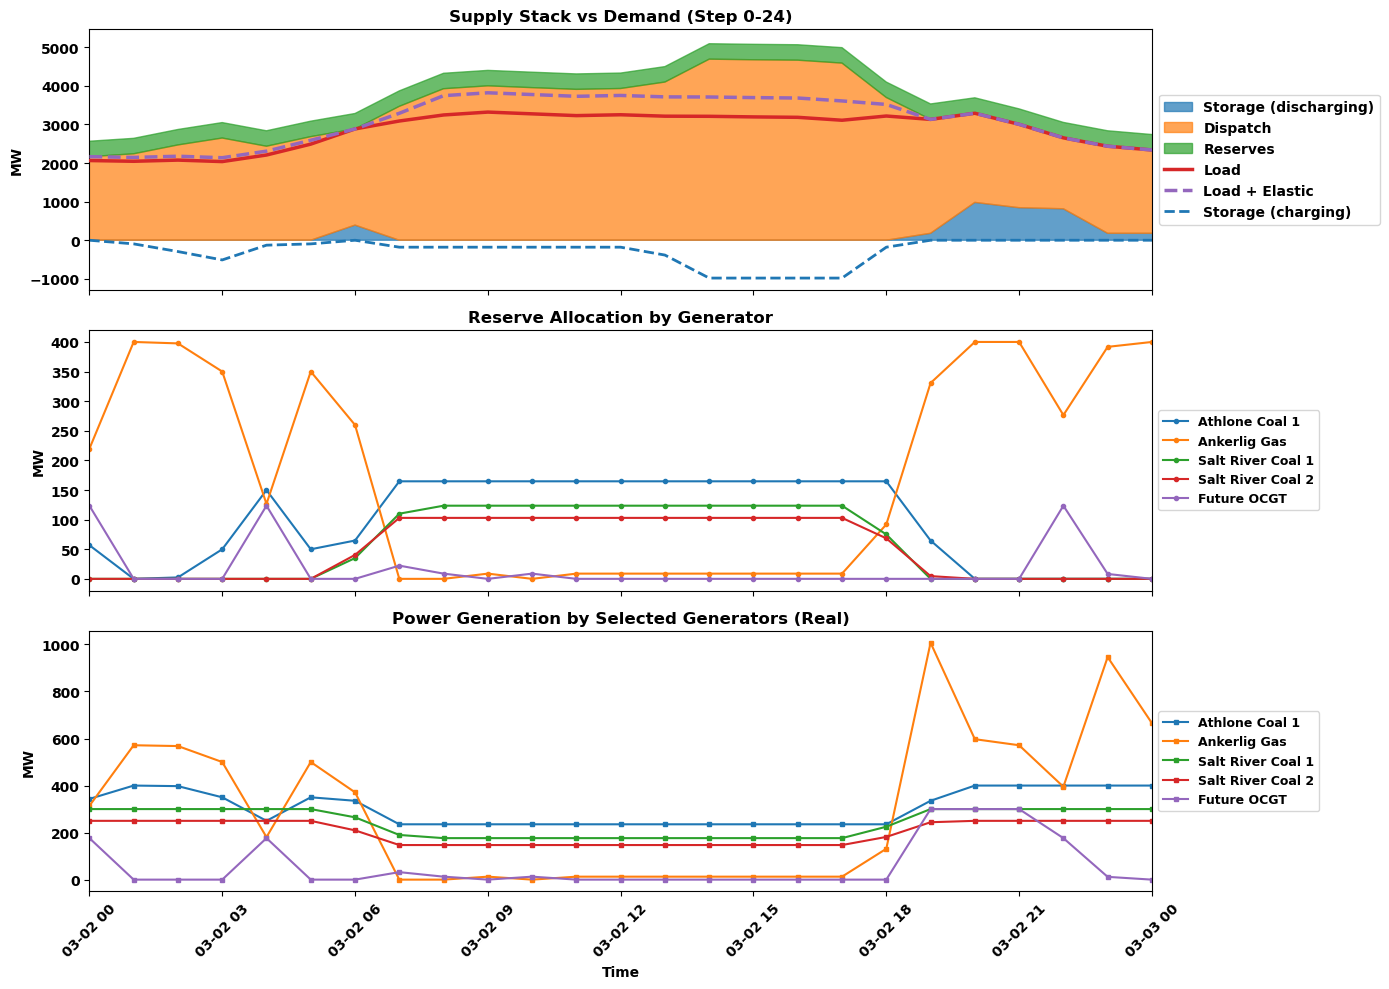

In [10]:

plot_period(0, 24) 

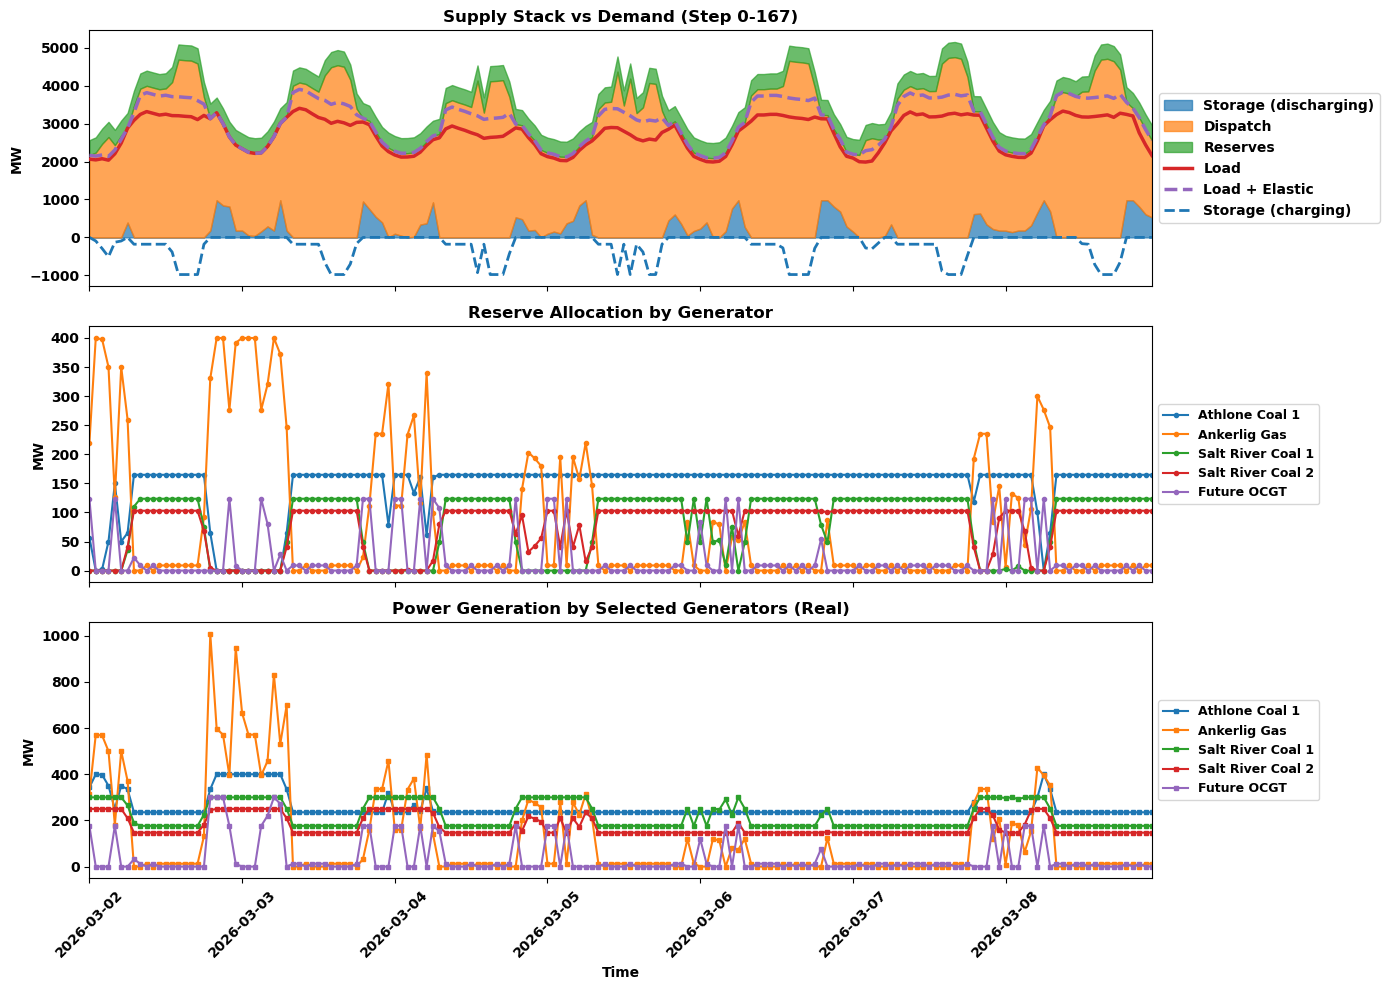

In [11]:
plot_period(0, 167)